In [1]:
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
import os
from src import RASPRoutines
import numpy as np
import pandas as pd

RASP = RASPRoutines.RASP_Routines()

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()


In [2]:
folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/'
# example file, replace as you wish. Always input as the absolute path of a raw string
RASP.cell_threshold1 = 100.
RASP.cell_threshold2 = 300.

In [4]:
RASP.focus_score_int

390.0

In [4]:
negative_control_folder = 'True_NegativeControl'
nc_folder = os.path.join(folder, negative_control_folder)

Radiality calibrated using negative control images in /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/True_NegativeControl. New flatness is 0.99 and new integrated gradient is 11.89. Parameters saved in /home/jsb92/Documents/pyRASP/default_analysis_parameters.


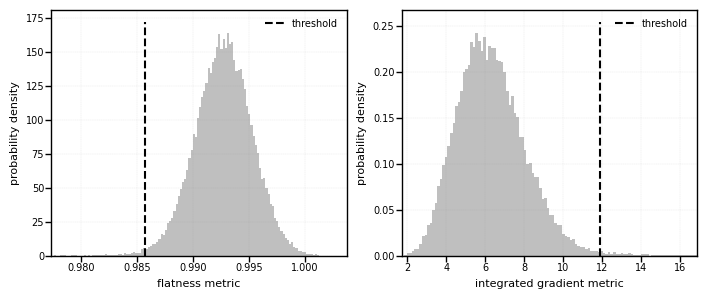

In [9]:
RASP.calibrate_radiality(folder=nc_folder, protein_string='C1')

In [10]:
""" the command below will run the analyse_images analysis:

            folder (string): Folder containing images
            imtype (string): Type of images being analysed. Default '.tif'
            thres (float): fraction of bright pixels accepted. Default 0.05.
            large_thres (float): large object intensity threshold. Default 100.
            gisgma (float): gaussian blurring parameter. Default 1.4.
            rwave (float): Ricker wavelent sigma. Default 2.
            protein_string (np.1darray): strings for protein-stained data. Default C1.
            cell_string (np.1darray): strings for cell-containing data. Default C0.
            if_filter (boolean): Filter images for focus. Default True.
            im_start (integer): Images to start from. Default 0.
            cell_analysis (boolean): Parameter where script also analyses cell
                images. Default True.
            one_savefile (boolean): Parameter that, if true, doesn't save a file. Default True.
                per image but amalgamates them into one file. Default True.
            disp (boolean): If true, prints when analysed an image stack. Default True.
            analyse_clr (boolean): If true, calculates the clr. If not, just coincidence. Default True.
            folder_recursion (boolean): If true, recursively finds folders and analyses each separately.
            error_reduction (boolean): If true, reduces error on the oligomer image using Huang's code
            
All have defaults except folder, which is necessary.
"""

overall_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/'

folders = os.listdir(overall_folder)
folders = np.sort([x for x in folders if negative_control_folder not in x and os.path.isdir(os.path.join(overall_folder, x))
                  and 'parameters' not in x and 'analysis' not in x])
for folder in folders:
    RASP.analyse_images(os.path.join(overall_folder, folder), protein_string="C1", cell_string="C0", 
                        focus_images="C0", thres=0.05, large_thres=250.0, 
                        cell_analysis=True, folder_recursive=True, if_filter=False)

Analysed image file 1/1    Time elapsed: 16.987 s

In [28]:
from src.PlottingFunctions import Plotter
from src import IOFunctions 
IO = IOFunctions.IO_Functions()
from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()
import pandas as pd

fov_1_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/Full Length Gastermin/5uM/FOV_1'
fov_1_analysisfolder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/Full Length Gastermin/5uM/FOV_1_analysis'

tiffs = H_F.file_search(fov_1_folder, '.tif', '')
csvs = H_F.file_search(fov_1_analysisfolder, '.csv', 'spot_analysis')

In [34]:
tiffs[0]

'/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260529_RASPDan/Full Length Gastermin/5uM/FOV_1/well4_30mins_mscarlet_fulllength_5uM_cmgreen_2_XY1768917987_Z00_T0_C0.tif'

In [29]:
img = IO.read_tiff(tiffs[0])
spots = pd.read_csv(csvs[0])

In [36]:
spots_f1 = spots[spots['image_filename'] == tiffs[0]]

In [ ]:


plots = Plotter()
fig, axs = plots.one_column_plot()
axs[0] = plots.image_scatter_plot(
  axs[0],
  img[z - 1, :, :],           # raw image at z-plane z
  xdata=spots_f1[spots_f1["z"] == z]["x"].to_numpy(),
  ydata=spots_f1[spots_f1["z"] == z]["y"].to_numpy(),
  label=f"z plane = {z}",
)

In [6]:
import os
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
from src import RASPRoutines
import polars as pl
import numpy as np
from src import IOFunctions
from src import AnalysisFunctions
from src import Image_Analysis_Functions
from src import HelperFunctions

RASP = RASPRoutines.RASP_Routines()
IO = IOFunctions.IO_Functions()
A_F = AnalysisFunctions.Analysis_Functions()
IA_F = Image_Analysis_Functions.ImageAnalysis_Functions()
H_F = HelperFunctions.Helper_Functions()

import warnings
from copy import copy

warnings.filterwarnings("ignore")

In [7]:
import os                                                             
import re                                                                                                                                                                                                                                                      
import pandas as pd                                                                                                                                                                                                                                            
from pathlib import Path                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                             
def collate_spot_analysis(root_dir, output_path="collated_data.h5"):
  """                                                                                                                                                                                                                                                        
  Recursively finds all spot_analysis.csv files under root_dir,
  tags each row with patient_id and group (HC or PD), and saves
  the collated DataFrame to an HDF5 file.                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
  HC: folder name starts with 'C' or 'PDC'                                                                                                                                                                                                                   
  PD: folder name starts with 'PD' (but not 'PDC')                                                                                                                                                                                                           
                                                                                                                                                                                                                                                             
  Patient ID extraction (from the immediate parent folder name):
    - If folder contains '-': take the substring before the first '-'                                                                                                                                                                                        
    - Otherwise: take the substring before the first '_'                                                                                                                                                                                                     

  Parameters                                                                                                                                                                                                                                                 
  ----------  
  root_dir : str or Path                                                                                                                                                                                                                                     
      Top-level directory to search recursively.
  output_path : str or Path
      Path for the output .h5 file.                                                                                                                                                                                                                          

  Returns                                                                                                                                                                                                                                                    
  -------     
  pd.DataFrame
      The collated DataFrame (also saved to output_path).
  """                                                                                                                                                                                                                                                        
  root_dir = Path(root_dir)
  records = []                                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                             
  for csv_path in sorted(root_dir.rglob("spot_analysis.csv")):
      folder_name = csv_path.parent.name                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                             
      # --- determine patient_id ---
      if "-" in folder_name:                                                                                                                                                                                                                                 
          patient_id = folder_name.split("-")[0]
      elif "_" in folder_name:
          patient_id = folder_name.split("_")[0]                                                                                                                                                                                                             
      else:
          patient_id = folder_name                                                                                                                                                                                                                           
              
      # --- determine group ---
      if re.match(r"^PDC", folder_name, re.IGNORECASE):
          group = "HC"                                                                                                                                                                                                                                       
      elif re.match(r"^C", folder_name, re.IGNORECASE):
          group = "HC"                                                                                                                                                                                                                                       
      elif re.match(r"^PD", folder_name, re.IGNORECASE):
          group = "PD"      
      else:   
          group = "unknown"

      try:                                                                                                                                                                                                                                                   
          df = pd.read_csv(csv_path)
      except Exception as e:                                                                                                                                                                                                                                 
          print(f"  [WARNING] Could not read {csv_path}: {e}")
          continue
                                                                                                                                                                                                                                                             
      df.insert(0, "patient_id", patient_id)
      df.insert(1, "group", group)                                                                                                                                                                                                                           
      df["source_file"] = str(csv_path)
      records.append(df)                                                                                                                                                                                                                                     
      print(f"  [{group}] {patient_id}  ←  {csv_path.relative_to(root_dir)}")
                                                                                                                                                                                                                                                             
  if not records:                                                                                                                                                                                                                                            
      print("No spot_analysis.csv files found.")                                                                                                                                                                                                             
      return pd.DataFrame()                                                                                                                                                                                                                                  
              
  collated = pd.concat(records, ignore_index=True)

  output_path = Path(output_path)                                                                                                                                                                                                                            
  collated.to_hdf(output_path, key="spot_analysis", mode="w", complevel=5, complib="blosc")
  print(f"\nSaved {len(collated):,} rows → {output_path}")                                                                                                                                                                                                   
  print(f"  HCs : {(collated['group']=='HC').sum():,} rows  "                                                                                                                                                                                                
        f"({collated.loc[collated['group']=='HC','patient_id'].nunique()} patients)")                                                                                                                                                                        
  print(f"  PDs : {(collated['group']=='PD').sum():,} rows  "                                                                                                                                                                                                
        f"({collated.loc[collated['group']=='PD','patient_id'].nunique()} patients)")                                                                                                                                                                        
                                                                                                                                                                                                                                                             
  return collated                                                                                                                                                                                                                                            

In [8]:
overall_folder = '/scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer'


In [9]:
# --- Usage --- 
df = collate_spot_analysis(overall_folder, output_path=os.path.join(overall_folder, "collated_data.h5"))

  [HC] C30  ←  C30-2_analysis/spot_analysis.csv
  [HC] C43  ←  C43-2_analysis/spot_analysis.csv
  [HC] C49  ←  C49-2_analysis/spot_analysis.csv
  [HC] C64  ←  C64-2_analysis/spot_analysis.csv
  [HC] C73  ←  C73-2_analysis/spot_analysis.csv
  [HC] C74  ←  C74-2_analysis/spot_analysis.csv
  [unknown] P420  ←  P420_Positive_analysis/spot_analysis.csv
  [PD] PD612  ←  PD612_analysis/spot_analysis.csv
  [PD] PD687  ←  PD687_analysis/spot_analysis.csv
  [PD] PD86  ←  PD86_analysis/spot_analysis.csv
  [PD] PD913  ←  PD913_analysis/spot_analysis.csv
  [PD] PD917  ←  PD917_analysis/spot_analysis.csv
  [PD] PD945  ←  PD945_analysis/spot_analysis.csv
  [HC] PDC35  ←  PDC35_analysis/spot_analysis.csv

Saved 353,570 rows → /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer/collated_data.h5
  HCs : 204,622 rows  (7 patients)
  PDs : 129,098 rows  (6 patients)


In [10]:
df.columns

Index(['patient_id', 'group', 'x', 'y', 'z', 'sum_intensity_in_photons',
       'bg_per_punctum', 'bg_per_pixel', 'zi', 'zf', 'image_filename',
       'source_file'],
      dtype='object')

In [11]:
cell_string = "C488"
protein_string = "C561"

patient_status = np.array(["PD", "HC"])
imtype = ".tif"
cell_size_threshold = 5000.
percentiles = [0]
upper_cell_size_threshold = 200000

In [12]:
overall_folder = '/scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer'
folders = os.listdir(overall_folder)

In [13]:
folders_touse = np.sort([os.path.join(overall_folder, x) for x in folders if '_analysis' in x and 'parameters' not in x])

In [100]:
for i, folder in enumerate(folders_touse):
    savename = os.path.join(folder, "spot_analysis.csv")
    if i == 0:
        to_analyse = pl.read_csv(savename)
    else:
        temp = pl.read_csv(savename)
        to_analyse = pl.concat([to_analyse, temp], rechunk=True)
overall_region_filtered, q1, q2, IQR = A_F.reject_outliers(
                to_analyse, k=4
            )

In [104]:
for folder in folders_touse:
    """the command below will run the analyse_images analysis:

        folder (string): Folder containing images
        imtype (string): Type of images being analysed. Default '.tif'
        thres (float): fraction of bright pixels accepted. Default 0.05.
        large_thres (float): large object intensity threshold. Default 100.
        gisgma (float): gaussian blurring parameter. Default 1.4.
        rwave (float): Ricker wavelent sigma. Default 2.
        protein_string (np.1darray): strings for protein-stained data. Default C1.
        cell_string (np.1darray): strings for cell-containing data. Default C0.
        if_filter (boolean): Filter images for focus. Default True.
        im_start (integer): Images to start from. Default 0.
        cell_analysis (boolean): Parameter where script also analyses cell
            images and computes colocalisation likelihood ratios. Default True.
        one_savefile (boolean): Parameter that, if true, doesn't save a file. Default True.
            per image but amalgamates them into one file. Default True.
        disp (boolean): If true, prints when analysed an image stack. Default True.
        analyse_clr (boolean): If true, calculates the clr. If not, just coincidence. Default True.
        error_reduction (boolean): If true, reduces error on the oligomer image using Huang's code

    All have defaults except folder, which is necessary.
    """
    # then, get the percentile brightness from PD
    savename = os.path.join(folder, "spot_analysis.csv")
    to_analyse = pl.read_csv(savename)
    analysis_data_raw, _, _, _ = A_F.reject_outliers(
                        to_analyse, q1=q1, q2=q2, IQR=IQR, k=4
                        )
    end_str = ""
    cell_punctum_analysis = (
        RASP.count_puncta_in_individual_cells_threshold_3D(
            copy(analysis_data_raw),
            savename,
            0,
            cell_string,
            protein_string,
            lower_cell_size_threshold=cell_size_threshold,
            upper_cell_size_threshold=upper_cell_size_threshold,
            erosionsize=0,
            threshold_upper=np.inf,
            imtype=".tif",
            blur_degree=1,
            replace_files=True,
            new_folder="CellAnalysis_OnlyLowerThreshold",
            end_string=end_str,
            dims=3,
            sigma1=2.0,
            sigma2=40.0,
            spacing=(0.5, 0.11, 0.11),
        )
    )
    del cell_punctum_analysis


Saved: /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer/C30-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
Saved: /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer/C43-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
Saved: /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer/C49-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
Saved: /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer/C64-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
Saved: /scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oli

In [112]:
import os                                                             
import re                                                                                                                                                                                                                                                      
import pandas as pd                                                                                                                                                                                                                                            
from pathlib import Path                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                             
def collate_incell_analysis(root_dir, output_path="collated_incell_data.h5"):
  """                                                                                                                                                                                                                                                        
  Recursively finds all CellAnalysis_ files under root_dir,
  tags each row with patient_id and group (HC or PD), and saves
  the collated DataFrame to an HDF5 file.                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
  HC: folder name starts with 'C' or 'PDC'                                                                                                                                                                                                                   
  PD: folder name starts with 'PD' (but not 'PDC')                                                                                                                                                                                                           
                                                                                                                                                                                                                                                             
  Patient ID extraction (from the immediate parent folder name):
    - If folder contains '-': take the substring before the first '-'                                                                                                                                                                                        
    - Otherwise: take the substring before the first '_'                                                                                                                                                                                                     

  Parameters                                                                                                                                                                                                                                                 
  ----------  
  root_dir : str or Path                                                                                                                                                                                                                                     
      Top-level directory to search recursively.
  output_path : str or Path
      Path for the output .h5 file.                                                                                                                                                                                                                          

  Returns                                                                                                                                                                                                                                                    
  -------     
  pd.DataFrame
      The collated DataFrame (also saved to output_path).
  """                                                                                                                                                                                                                                                        
  root_dir = Path(root_dir)
  records = []                                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                             
  for csv_path in sorted(root_dir.rglob("single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv")):
      folder_name = csv_path.parent.parent.name                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                             
      # --- determine patient_id ---
      if "-" in folder_name:                                                                                                                                                                                                                                 
          patient_id = folder_name.split("-")[0]
      elif "_" in folder_name:
          patient_id = folder_name.split("_")[0]                                                                                                                                                                                                             
      else:
          patient_id = folder_name                                                                                                                                                                                                                           
              
      # --- determine group ---
      if re.match(r"^PDC", folder_name, re.IGNORECASE):
          group = "HC"                                                                                                                                                                                                                                       
      elif re.match(r"^C", folder_name, re.IGNORECASE):
          group = "HC"                                                                                                                                                                                                                                       
      elif re.match(r"^PD", folder_name, re.IGNORECASE):
          group = "PD"      
      else:   
          group = "unknown"

      try:                                                                                                                                                                                                                                                   
          df = pd.read_csv(csv_path)
      except Exception as e:                                                                                                                                                                                                                                 
          print(f"  [WARNING] Could not read {csv_path}: {e}")
          continue
                                                                                                                                                                                                                                                             
      df.insert(0, "patient_id", patient_id)
      df.insert(1, "group", group)                                                                                                                                                                                                                           
      df["source_file"] = str(csv_path)
      records.append(df)                                                                                                                                                                                                                                     
      print(f"  [{group}] {patient_id}  ←  {csv_path.relative_to(root_dir)}")
                                                                                                                                                                                                                                                             
  if not records:                                                                                                                                                                                                                                            
      print("No single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv.csv files found.")                                                                                                                                                                                                             
      return pd.DataFrame()                                                                                                                                                                                                                                  
              
  collated = pd.concat(records, ignore_index=True)

  output_path = Path(output_path)                                                                                                                                                                                                                            
  collated.to_hdf(output_path, key="data", mode="w", complevel=5, complib="blosc")
  print(f"\nSaved {len(collated):,} rows → {output_path}")                                                                                                                                                                                                   
  print(f"  HCs : {(collated['group']=='HC').sum():,} rows  "                                                                                                                                                                                                
        f"({collated.loc[collated['group']=='HC','patient_id'].nunique()} patients)")                                                                                                                                                                        
  print(f"  PDs : {(collated['group']=='PD').sum():,} rows  "                                                                                                                                                                                                
        f"({collated.loc[collated['group']=='PD','patient_id'].nunique()} patients)")                                                                                                                                                                        
                                                                                                                                                                                                                                                             
  return collated                                                                                                                                                                                                                                            

In [113]:
root_dir = Path(overall_folder)
a = sorted(root_dir.rglob("single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv"))

In [115]:
overall_folder = '/scratch/sycamore-asap/ASAP_Imaging_Data/Joe/20260326_Oligomer'

df = collate_incell_analysis(overall_folder, output_path=os.path.join(overall_folder, "collated_incell_data.h5"))

  [HC] C30  ←  C30-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
  [HC] C43  ←  C43-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
  [HC] C49  ←  C49-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
  [HC] C64  ←  C64-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
  [HC] C73  ←  C73-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincellsize_5000_maxcellsize_200000_photonthreshold_0_photons__abovethreshold.csv
  [HC] C74  ←  C74-2_analysis/CellAnalysis_OnlyLowerThreshold/single_cell_coincidence_3Danalysis_mincells

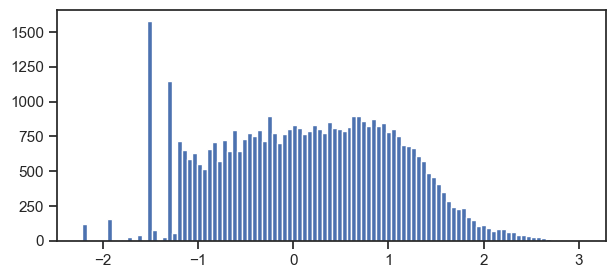

In [118]:
plt.hist(np.log10(df['area/um3']), 100);
plt.show()

In [119]:
microglial_volume = (4/3)*np.pi*5**3

In [120]:
microglial_volume

523.5987755982989

In [121]:
patients = np.unique(df['patient_id'])

In [122]:
df = df[df['n_puncta_in_cell'] > 0]
df = df.reset_index()

In [130]:
df.to_hdf(os.path.join(overall_folder, 'collated_incell_data.h5'), key="data", mode="w", complevel=5, complib="blosc")

In [123]:
HC_patients = np.sort([x for x in patients if 'C' in x or 'PDC' in x])
PD_patients = np.sort([x for x in patients if 'PD' in x and 'PDC' not in x])

In [124]:
mean_HC_incell = np.zeros(len(HC_patients))
mean_PD_incell = np.zeros(len(PD_patients))

for i, patient in enumerate(HC_patients):
    mean_HC_incell[i] = np.mean(df[df['patient_id'] == patient]['n_puncta_in_cell']/df[df['patient_id'] == patient]['area/um3'])*microglial_volume
for i, patient in enumerate(PD_patients):    
    mean_PD_incell[i] = np.mean(df[df['patient_id'] == patient]['n_puncta_in_cell']/df[df['patient_id'] == patient]['area/um3'])*microglial_volume
    

In [125]:
mean_HC_incell

array([ 58.7965676 ,  54.34742002,  60.16824586, 115.88194819,
        62.24807605, 144.55680758,  41.4875472 ])

In [126]:
mean_PD_incell

array([149.31360755,  78.61189842, 185.63321994, 130.01990266,
       143.00581075,  43.62269729])

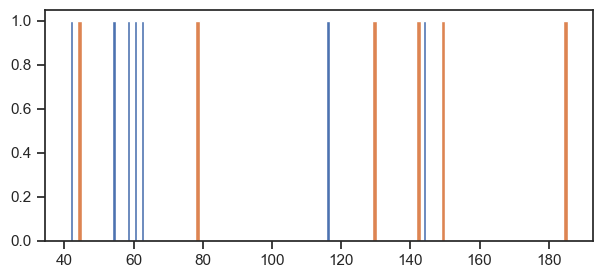

In [127]:
plt.hist(mean_HC_incell, 100);
plt.hist(mean_PD_incell, 100);
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()


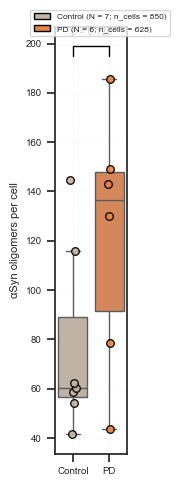

Mann-Whitney U: statistic = 10.000, p = 0.1375
Control: N = 7 donors, n_cells = 850
PD:      N = 6 donors, n_cells = 628


In [131]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import pandas as pd

# ============================================================================
# Box plot: HC vs PD oligomers per cell (styled after COSMX Fig4d plots)
# ============================================================================

sns.set_theme(style="ticks")
palette = {'PD': '#E88247', 'Control': '#C3B3A1'}
hue_order = ['Control', 'PD']

# Build per-patient means dataframe (box derives from these same values)
df_means = pd.DataFrame({
    'oligomers_per_cell': np.concatenate([mean_HC_incell, mean_PD_incell]),
    'disease': ['Control'] * len(mean_HC_incell) + ['PD'] * len(mean_PD_incell),
    'patient_id': list(HC_patients) + list(PD_patients)
})

# Cell counts (reported in legend)
n_cells_HC = len(df[df['patient_id'].isin(HC_patients)])
n_cells_PD = len(df[df['patient_id'].isin(PD_patients)])
n_donors_HC = len(HC_patients)
n_donors_PD = len(PD_patients)

# Mann-Whitney U test on per-patient means
stat, p_val = stats.mannwhitneyu(mean_HC_incell, mean_PD_incell, alternative='two-sided')

# Create figure
fig, ax = plt.subplots(figsize=(3, 5))

sns.boxplot(
    data=df_means,
    x='disease',
    y='oligomers_per_cell',
    order=hue_order,
    palette=palette,
    showfliers=False,
    ax=ax
)

# Scatter the same per-patient means on top
for j, (disease, means) in enumerate(zip(hue_order, [mean_HC_incell, mean_PD_incell])):
    for val in means:
        jitter = np.random.uniform(-0.1, 0.1)
        ax.scatter(j + jitter, val, color=palette[disease], edgecolor='black', s=30, alpha=0.9, zorder=10)

ax.tick_params(labelsize=7)

# Annotate p-value with bracket
y_max = df_means['oligomers_per_cell'].max()
y_line = y_max * 1.05
ax.plot([0, 0, 1, 1], [y_line, y_line * 1.02, y_line * 1.02, y_line], color='black', lw=1)
p_text = f'p = {p_val:.3f}' if p_val >= 0.001 else 'p < 0.001'
ax.text(0.5, y_line * 1.04, p_text, ha='center', va='bottom', fontsize=7)

# Custom legend with donor and cell counts
legend_elements = [
    Patch(facecolor=palette['Control'], edgecolor='black',
          label=f'Control (N = {n_donors_HC}; n_cells = {n_cells_HC:,})'),
    Patch(facecolor=palette['PD'], edgecolor='black',
          label=f'PD (N = {n_donors_PD}; n_cells = {n_cells_PD:,})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=6, bbox_to_anchor=(1.65, 1.05))

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.25)
plt.ylabel('\u03b1Syn oligomers per cell', fontsize=8)
ax.set(xlabel=None)
plt.tight_layout()
plt.savefig('COSMX_Patients_Rebeka_Plot.svg', dpi=600, format='svg')
plt.show()

print(f'Mann-Whitney U: statistic = {stat:.3f}, p = {p_val:.4f}')
print(f'Control: N = {n_donors_HC} donors, n_cells = {n_cells_HC:,}')
print(f'PD:      N = {n_donors_PD} donors, n_cells = {n_cells_PD:,}')
